# Algorytmika i matematyka uczenia maszynowego 
## Laboratorium 7


### Zadanie 1

W mieście liczącym 700 000 mieszkańców pojawiła się choroba, na którą choruje 1 osoba na 1000. Nie wiadomo, które osoby są chore, ale dostępny jest test diagnostyczny, którego zarówno czułość i swoistość wynosi 99% (tzn. prawdopodobieństwo uzyskania poprawnego wyniku – zarówno pozytywnego u osoby chorej, jak i negatywnego u osoby zdrowej – wynosi 99%).
Jakie jest prawdopodobieństwo, że pacjent, który otrzymał pozytywny wynik testu jest rzeczywiście chory?

#### A)

Przeprowadź symulację komputerową opisanego scenariusza:

- Utwórz listę mieszkańców o wielkości 700 tys. elementów, gdzie każdy element reprezentuje mieszkańca. Każdy mieszkaniec powinien posiadać dwie właściwości: *stan zdrowia* (zdrowy/chory) oraz *wynik diagnozy* (pozytywny/negatywny).
- Losowo wybieramy 700 mieszkańców (bo 1 na 1000 osób choruje) i przypisz im *stan zdrowia* jako *chory*. Uwaga: należy dopilnować, aby nie wylosowała się dwukrotnie ta sama osoba.
- Spośród osób chorych wylosuj 1% i przypisz im błędny wynik testu (*wynik diagnozy* = negatywny). Spośród osób zdrowych wylosuj 1% i przypisz im błędny wynik testu (*wynik diagnozy* = pozytywny).
- Korzystając z utworzonej listy mieszkańców, oblicz prawdopodobieństwo, że osoba z pozytywnym wynikiem testu jest rzeczywiście chora, według wzoru: `liczba osób chorych z wynikiem pozytywnym` / `liczba wszystkich osob z wynikiem pozytywnym`.

In [24]:
import numpy as np

num_of_people = 700000
sick_rate = 0.001

def simulate_positive_given_sick(num_of_people=700000, sick_rate=0.001, sensitivity=0.99, specificity=0.99):
    population = np.zeros((int(num_of_people), 2))
    num_sick = int(num_of_people * sick_rate)
    sick_people = np.random.choice(num_of_people, num_sick, replace=False)
    population[sick_people, 0] = 1  
    population[sick_people, 1] = 1  

    num_false_negative = int((1 - sensitivity) * num_sick)
    if num_false_negative > 0:
        false_negative = np.random.choice(sick_people, num_false_negative, replace=False)
        population[false_negative, 1] = 0  

    healthy_people = np.where(population[:, 0] == 0)[0]
    num_false_positive = int((1 - specificity) * len(healthy_people))
    if num_false_positive > 0:
        false_positive = np.random.choice(healthy_people, num_false_positive, replace=False)
        population[false_positive, 1] = 1  

    positive_tests = population[:, 1] == 1
    sick_and_positive = (population[:, 0] == 1) & positive_tests
    prob = sick_and_positive.sum() / positive_tests.sum()
    return prob

prob = simulate_positive_given_sick()

print(f"Prawdopodobieństwo, że osoba z pozytywnym wynikiem testu jest chora: {prob*100:.2f}%")

Prawdopodobieństwo, że osoba z pozytywnym wynikiem testu jest chora: 9.02%


#### B)

Napisz funkcję, która zwróci wynik obliczony ze wzoru Bayesa. Następnie zmierz i porównaj czas wykonania obliczeń w obu przypadkach: symulacji komputerowej oraz wzoru Bayesa.




In [25]:
import time

def bayes_positive_given_sick(sensitivity, specificity, prevalence):
    p_positive = sensitivity * prevalence + (1 - specificity) * (1 - prevalence)
    p_sick_given_positive = (sensitivity * prevalence) / p_positive
    return p_sick_given_positive

start_sim = time.time()
sim_result = simulate_positive_given_sick()
sim_time = time.time() - start_sim

start_bayes = time.time()
bayes_result = bayes_positive_given_sick(0.99, 0.99, 0.001)
bayes_time = time.time() - start_bayes

print(f"Wynik symulacji: {sim_result*100:.2f}% (czas: {sim_time} ms)")
print(f"Wynik wzoru Bayesa: {bayes_result*100:.2f}% (czas: {bayes_time} ms)")

Wynik symulacji: 9.02% (czas: 0.06801533699035645 ms)
Wynik wzoru Bayesa: 9.02% (czas: 0.0 ms)


#### C)

Wyświetl wykres, gdzie na osi X znajduje się czułość i swoistość testu (przyjmij zakres 50%-99.99%), a na osi Y znajduje się _prawdopodobieństwo, że osoba z pozytywnym wynikiem jest chora_ (użyj funkcji z podpunktu B).

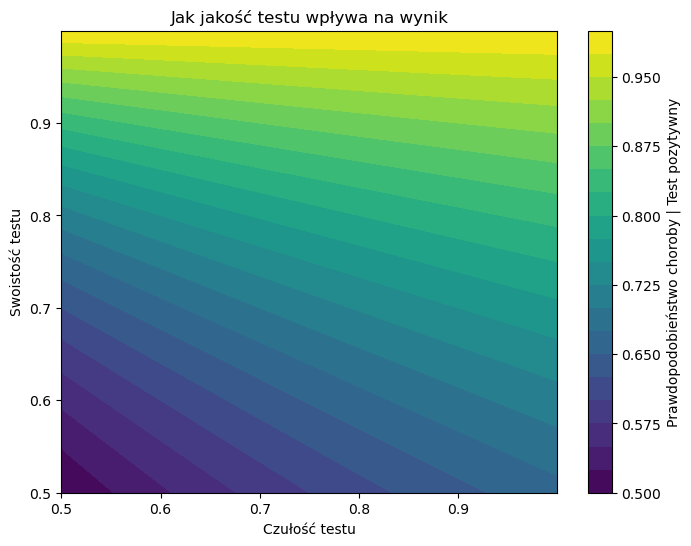

In [26]:
import numpy as np
import matplotlib.pyplot as plt

def bayes_positive_given_sick(sensitivity, specificity, prevalence):
    sensitivity = np.asarray(sensitivity)
    specificity = np.asarray(specificity)
    p_positive = sensitivity * prevalence + (1 - specificity) * (1 - prevalence)
    return (sensitivity * prevalence) / p_positive

prevalence = 0.5

sensitivity_range = np.linspace(0.5, 0.9999, 200)
specificity_range = np.linspace(0.5, 0.9999, 200)
SENS, SPEC = np.meshgrid(sensitivity_range, specificity_range)
prob_grid = bayes_positive_given_sick(SENS, SPEC, prevalence)

plt.figure(figsize=(8, 6))
colors = plt.contourf(SENS, SPEC, prob_grid, levels=20, cmap='viridis')
plt.colorbar(colors, label='Prawdopodobieństwo choroby | Test pozytywny')
plt.xlabel('Czułość testu')
plt.ylabel('Swoistość testu')
plt.title('Jak jakość testu wpływa na wynik')
plt.show()

### Zadanie 2

Sprawdź (symulacją) ile średnio razy należy losować 13 kart, aby trafia się "ręka" zawierająca $\ge 8$ kart w jednym kolorze. Możemy to zrobić następująco: losujemy 13 kart z 52 (wiec "ręki" jak w brydzu) tak długo, aż w którymkolwiek kolorze dostaniemy $\ge 8$ kart, zapisujemy liczbę przeprowadzonych losowań i podejmujemy kolejną próbę. Przeprowadź 1000 takich prób i oblicz średnią liczbę losowań. 

Dodatkowo wypisz jedną (np. ostatnią) wylosowaną "rękę".

In [27]:
import random
import numpy as np

def simulate_hand():
    deck = ['C'] * 13 + ['D'] * 13 + ['H'] * 13 + ['S'] * 13
    count = 0
    while True:
        count += 1
        hand = random.sample(deck, 13)

        c = hand.count('C')
        d = hand.count('D')
        h = hand.count('H')
        s = hand.count('S')

        if c >= 8 or d >= 8 or h >= 8 or s >= 8:
            return count

number_of_trials = 1000
results = [simulate_hand() for _ in range(number_of_trials)]
print(f'Średnia liczba losowań: {np.mean(results):.2f} przy {number_of_trials} próbach')


Średnia liczba losowań: 195.41 przy 1000 próbach
